<a href="https://colab.research.google.com/github/sajjkavinda/ML-based-Intrution-detection-system/blob/main/DecisionTree_Model_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Decision Tree Model Training and Evaluation

The objective of this stage is to evaluate the capability of a lightweight supervised learning algorithm in detecting malicious network traffic while considering computational efficiency and model performance.

In [32]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Import libraries

In [33]:
import pandas as pd
import numpy as np
import time
import pickle
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import joblib

Set paths to the Dataset and Output

In [34]:
PROJECT_DIR = Path("/content/drive/MyDrive/MSc_Dissertation")

PROCESSED_DIR = PROJECT_DIR / "Dataset/Processed"

RESULTS_DIR = PROJECT_DIR / "Results"

MODEL_DIR = RESULTS_DIR / "Models"

MODEL_DIR.mkdir(parents=True, exist_ok=True)

Load Training and Test Datasets

In [35]:
with open(PROCESSED_DIR / "X_train.pkl", "rb") as f:
    X_train = pickle.load(f)

with open(PROCESSED_DIR / "X_test.pkl", "rb") as f:
    X_test = pickle.load(f)

with open(PROCESSED_DIR / "y_train.pkl", "rb") as f:
    y_train = pickle.load(f)

with open(PROCESSED_DIR / "y_test.pkl", "rb") as f:
    y_test = pickle.load(f)


print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (278560, 30)
Testing data: (69641, 30)


Create the Decision Tree Model

In [36]:
dt_model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=20,
    random_state=42
)

Train the model

In [37]:
dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=8,
    min_samples_split=100,
    min_samples_leaf=50
)

start_time = time.time()


dt.fit(
    X_train,
    y_train
)

training_time = time.time() - start_time


print(
    f"Training time: {training_time:.2f} seconds"
)

Training time: 1.91 seconds


Make predictions

In [38]:
start_prediction = time.time()

y_pred = dt.predict(
    X_test
)

prediction_time = time.time() - start_prediction


print(
    f"Prediction time: {prediction_time:.4f} seconds"
)

Prediction time: 0.0038 seconds


Evaluate performance

In [39]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    f"Accuracy: {accuracy:.4f}"
)

Accuracy: 0.9995


Classification report

In [40]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     55776
           1       1.00      1.00      1.00     13865

    accuracy                           1.00     69641
   macro avg       1.00      1.00      1.00     69641
weighted avg       1.00      1.00      1.00     69641



Confusion matrix

[[55740    36]
 [    2 13863]]


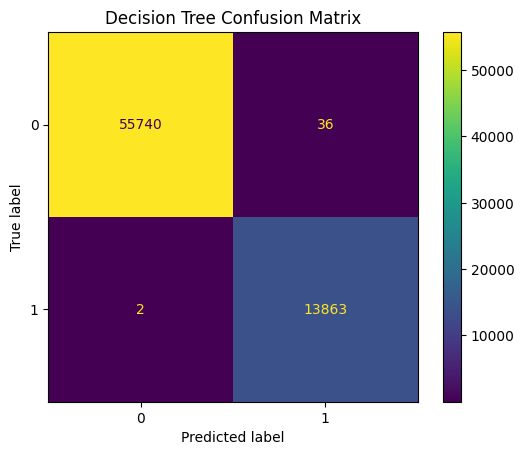

In [41]:
cm = confusion_matrix(
    y_test,
    y_pred
)


print(cm)


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title(
    "Decision Tree Confusion Matrix"
)

plt.show()

Feature importance

In [42]:
feature_importance = pd.DataFrame(
    {
        "Feature": X_train.columns,
        "Importance": dt.feature_importances_
    }
)


feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)


feature_importance.head(20)

,Feature,Importance
0,Fwd Seg Size Min,0.546109
18,Bwd IAT Min,0.432095
19,Bwd Pkt Len Mean,0.007211
15,Bwd Pkt Len Max,0.005319
1,Init Fwd Win Byts,0.003239
20,Init Bwd Win Byts,0.002239
8,Pkt Len Max,0.001413
6,Fwd Pkt Len Max,0.001348
10,Flow IAT Max,0.000702
7,Fwd IAT Mean,0.000179


Plot feature importance

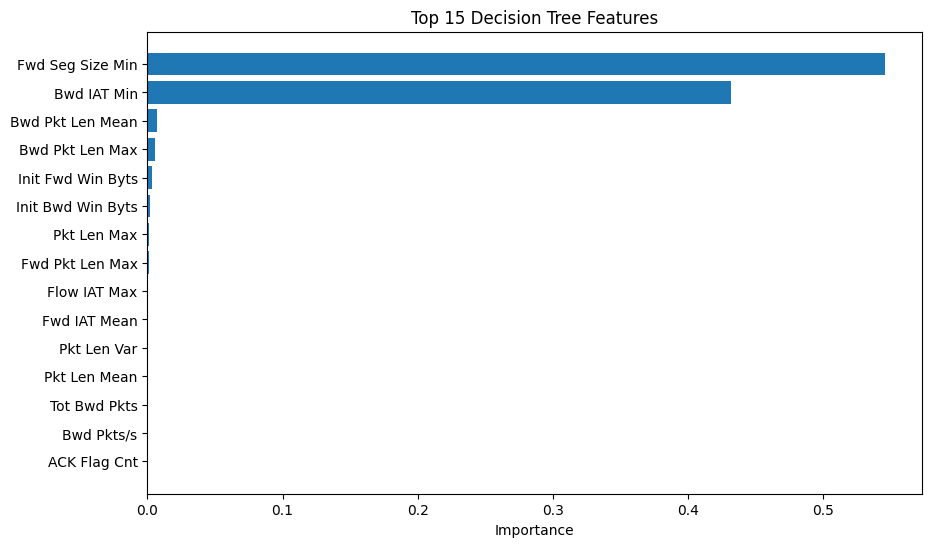

In [43]:
top_features = feature_importance.head(15)


plt.figure(figsize=(10,6))


plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)


plt.gca().invert_yaxis()


plt.xlabel(
    "Importance"
)

plt.title(
    "Top 15 Decision Tree Features"
)


plt.show()

Save the model

In [44]:
MODEL_PATH = MODEL_DIR / "decision_tree_model_expanded.pkl"

joblib.dump(
    dt,
    MODEL_PATH
)


print(
    "Model saved:"
)

print(
    MODEL_PATH
)

Model saved:
/content/drive/MyDrive/MSc_Dissertation/Results/Models/decision_tree_model_expanded.pkl


Save the results

In [45]:
results = pd.DataFrame(
    {
        "Model": ["Decision Tree"],
        "Accuracy": [accuracy],
        "Training Time (seconds)": [training_time],
        "Prediction Time (seconds)": [prediction_time]
    }
)


RESULT_PATH = RESULTS_DIR / "Models" / "decision_tree_results_expanded.csv"

results.to_csv(
    RESULT_PATH,
    index=False
)


results

,Model,Accuracy,Training Time (seconds),Prediction Time (seconds)
0,Decision Tree,0.999454,1.906979,0.003829
